In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
titanic = pd.read_csv('titanic.csv')

In [6]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
titanic = titanic.drop(columns=['Cabin'])
print("Coluna Cabin eliminada!")
print(f"Colunas restantes: {titanic.shape[1]}")

Coluna Cabin eliminada!
Colunas restantes: 11


In [9]:
mediana_age = titanic['Age'].median()
titanic['Age'] = titanic['Age'].fillna(mediana_age)
print(f"Nulos em Age preenchidos com a mediana: {mediana_age} anos")

Nulos em Age preenchidos com a mediana: 28.0 anos


In [10]:

moda_embarked = titanic['Embarked'].mode()[0]
titanic['Embarked'] = titanic['Embarked'].fillna(moda_embarked)
print(f"Nulos em Embarked preenchidos com: {moda_embarked}")

Nulos em Embarked preenchidos com: S


In [11]:
titanic.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

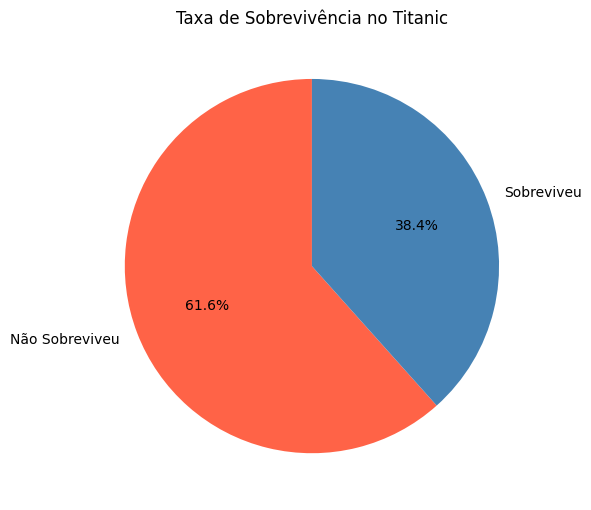

In [12]:
sobreviventes = titanic['Survived'].value_counts()
labels = ['Não Sobreviveu', 'Sobreviveu']
cores = ['tomato', 'steelblue']

plt.figure(figsize=(6, 6))
plt.pie(sobreviventes, labels=labels, colors=cores, autopct='%1.1f%%', startangle=90)
plt.title('Taxa de Sobrevivência no Titanic')
plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_37872\2209322730.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic, x='Sex', y='Survived', palette=['steelblue', 'tomato'])


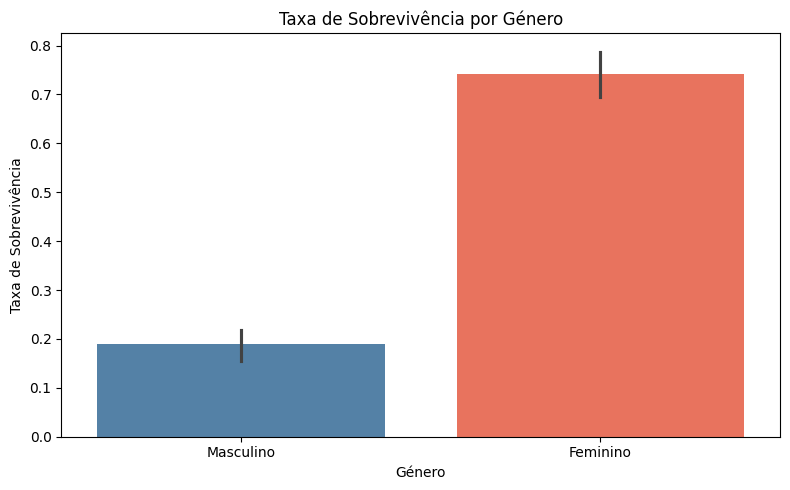

In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(data=titanic, x='Sex', y='Survived', palette=['steelblue', 'tomato'])
plt.title('Taxa de Sobrevivência por Género')
plt.xlabel('Género')
plt.ylabel('Taxa de Sobrevivência')
plt.xticks([0, 1], ['Masculino', 'Feminino'])
plt.tight_layout()
plt.show()

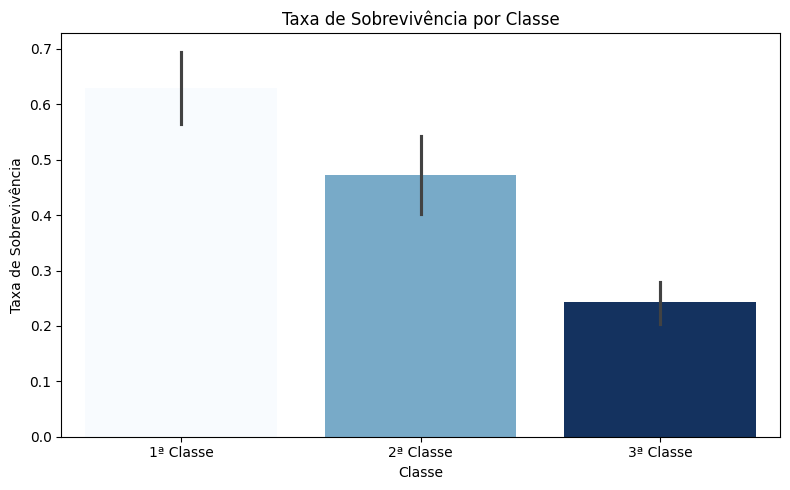

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(data=titanic, x='Pclass', y='Survived', hue='Pclass', palette='Blues', legend=False)
plt.title('Taxa de Sobrevivência por Classe')
plt.xlabel('Classe')
plt.ylabel('Taxa de Sobrevivência')
plt.xticks([0, 1, 2], ['1ª Classe', '2ª Classe', '3ª Classe'])
plt.tight_layout()
plt.show()

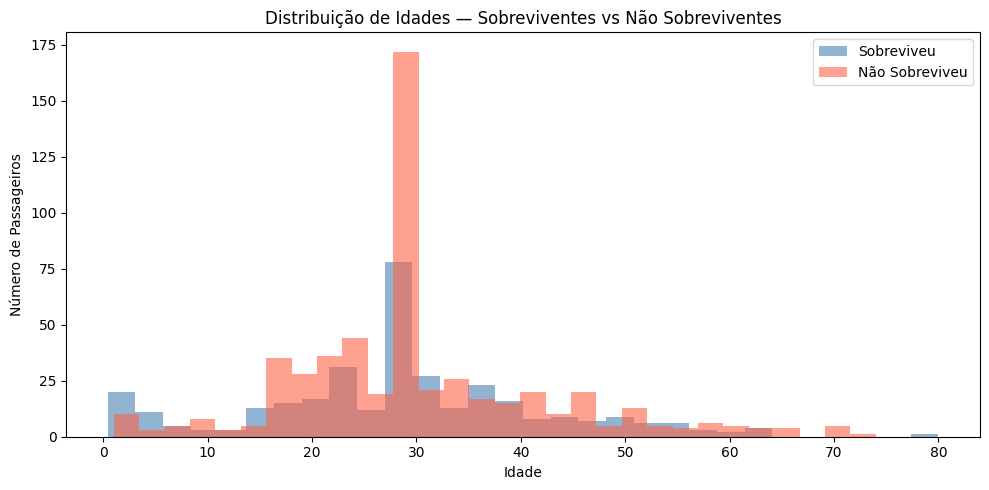

In [15]:
plt.figure(figsize=(10, 5))
plt.hist(titanic[titanic['Survived'] == 1]['Age'], bins=30, alpha=0.6, color='steelblue', label='Sobreviveu')
plt.hist(titanic[titanic['Survived'] == 0]['Age'], bins=30, alpha=0.6, color='tomato', label='Não Sobreviveu')
plt.title('Distribuição de Idades — Sobreviventes vs Não Sobreviventes')
plt.xlabel('Idade')
plt.ylabel('Número de Passageiros')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusões — Análise do Titanic

### Limpeza de dados realizada
- Eliminada coluna **Cabin** (77% de valores nulos)
- **Age** preenchida com a mediana (28 anos)
- **Embarked** preenchida com a moda (Southampton)

### Principais insights

**1. Taxa geral de sobrevivência**
Apenas 38.4% dos passageiros sobreviveu — 61.6% perdeu a vida.

**2. Género foi determinante**
Mulheres tiveram 74% de taxa de sobrevivência vs 19% dos homens.
A regra "mulheres e crianças primeiro" foi aplicada.

**3. Classe social influenciou a sobrevivência**
1ª Classe: ~63% | 2ª Classe: ~47% | 3ª Classe: ~24%
Passageiros mais pobres tiveram menos acesso aos botes salva-vidas.

**4. Crianças tiveram prioridade**
Passageiros com menos de 10 anos tiveram maior taxa de sobrevivência
comparado com adultos jovens.